In [61]:
import pandas as pd

train_df = pd.read_csv('../../data/titanic_train.csv')
test_df = pd.read_csv('../../data/titanic_test.csv')

In [62]:
from sklearn.impute import SimpleImputer

train_df = train_df.drop(['Cabin', 'Name', 'Ticket', 'Fare', 'PassengerId'], axis=1)
test_df = test_df.drop(['Cabin', 'Name', 'Ticket', 'Fare', 'PassengerId'], axis=1)

mean_imputer = SimpleImputer(strategy='mean')
train_df['Age'] = mean_imputer.fit_transform(train_df[['Age']])
test_df['Age'] = mean_imputer.fit_transform(test_df[['Age']])

freq_imputer = SimpleImputer(strategy='most_frequent')
train_df.iloc[:, :] = freq_imputer.fit_transform(train_df)
test_df.iloc[:, :] = freq_imputer.fit_transform(test_df)

In [63]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
ordinal_cat_cols = ["Pclass", "SibSp", "Parch"]

train_df[ordinal_cat_cols] = train_df[ordinal_cat_cols].apply(label_encoder.fit_transform)
test_df[ordinal_cat_cols] = test_df[ordinal_cat_cols].apply(label_encoder.fit_transform)

In [64]:
nominal_cat_cols = ["Sex", "Embarked"]

train_df = pd.get_dummies(train_df, columns=nominal_cat_cols)
test_df = pd.get_dummies(test_df, columns=nominal_cat_cols)

In [65]:
train_df[:3]

,Survived,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0,2,22.0,1,0,False,True,False,False,True
1,1,0,38.0,1,0,True,False,True,False,False
2,1,2,26.0,0,0,True,False,False,False,True


In [66]:
test_df[:3]

,Pclass,Age,SibSp,Parch,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,2,34.5,0,0,False,True,False,True,False
1,2,47.0,1,0,True,False,False,False,True
2,1,62.0,0,0,False,True,False,True,False


In [67]:
X = train_df.drop(columns=["Survived"])
y = train_df["Survived"]

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
test_df_scaled = scaler.fit_transform(test_df)

In [69]:
from sklearn.model_selection import train_test_split

x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled = train_test_split(X_scaled, y, test_size=0.2, random_state=1)

In [70]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(x_train_scaled, y_train_scaled)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [71]:
from sklearn.metrics import accuracy_score

x_train_predicted = model.predict(x_train_scaled)
x_test_predicted = model.predict(x_test_scaled)
a = accuracy_score(y_train_scaled, x_train_predicted) * 100
b = accuracy_score(y_test_scaled, x_test_predicted) * 100

In [72]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(f"Accuracy_Score of {model} model on Training Data is:", a)
print(f"Accuracy_Score of {model} model on Testing Data is:", b)
print("------------------------------------------------------------------------")
print(f"Precision Score of {model} model is:", precision_score(y_test_scaled, x_test_predicted))
print(f"Recall Score of {model} model is:", recall_score(y_test_scaled, x_test_predicted))
print(f"F1 Score of {model} model is:", f1_score(y_test_scaled, x_test_predicted))
print("------------------------------------------------------------------------")

Accuracy_Score of LogisticRegression() model on Training Data is: 79.63483146067416
Accuracy_Score of LogisticRegression() model on Testing Data is: 79.88826815642457
------------------------------------------------------------------------
Precision Score of LogisticRegression() model is: 0.7605633802816901
Recall Score of LogisticRegression() model is: 0.7397260273972602
F1 Score of LogisticRegression() model is: 0.75
------------------------------------------------------------------------


Confusion Matrix of LogisticRegression() model is:


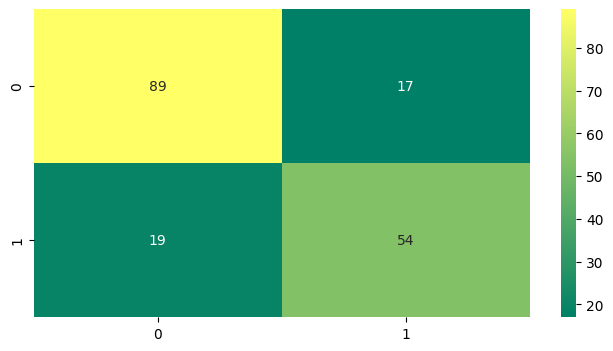

In [73]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

print(f"Confusion Matrix of {model} model is:")
cm = confusion_matrix(y_test_scaled, x_test_predicted)
plt.figure(figsize=(8, 4))
sns.heatmap(cm, annot=True, fmt="g", cmap="summer")
plt.show()